# 03 - MLflow: Dual-Graph Interaction GNN for Solubility

Same pipeline as notebook 02, with MLflow experiment tracking integrated.

In [1]:
import math
import random
import numpy as np
import pandas as pd
from rdkit import Chem

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import mlflow
    import mlflow.pytorch
    MLFLOW_AVAILABLE = True
except Exception:
    MLFLOW_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('MLflow available:', MLFLOW_AVAILABLE)

Device: cpu
MLflow available: True


In [2]:
CSV_PATH = '../data/processed/solubility_pairs.csv'
BATCH_SIZE = 64
HIDDEN_DIM = 96
MESSAGE_STEPS = 3
DROPOUT = 0.1
LR = 1e-3
WEIGHT_DECAY = 1e-5
EPOCHS = 14
DATA_FRACTION = 1.0

EXPERIMENT_NAME = 'interaction_solubility_gnn'
RUN_NAME = 'dual_graph_cross_attention'
TRACKING_URI = 'sqlite:///../mlruns/mlflow.db'  # SQLite avoids MLflow 3.x 500 bug with file:// backend


In [3]:
df = pd.read_csv(CSV_PATH)
if DATA_FRACTION < 1.0:
    df = df.sample(frac=DATA_FRACTION, random_state=SEED).reset_index(drop=True)

valid_mask = df['solute_smiles'].map(lambda s: Chem.MolFromSmiles(str(s)) is not None) & df['solvent_smiles'].map(lambda s: Chem.MolFromSmiles(str(s)) is not None)
df = df[valid_mask].reset_index(drop=True)
print('Rows used:', len(df))
df.head()

Rows used: 100983


,solute_smiles,solvent_smiles,logS,temp_k
0,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-1.996419,311.25
1,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-1.696799,314.65
2,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-1.476824,319.15
3,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-1.079064,322.15
4,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-0.632111,324.15


In [4]:
# Atom vocabulary
ALLOWED_ATOMS = ['C', 'H', 'O', 'N', 'S', 'Cl', 'F', 'Br', 'P', 'I', 'UNK']
ATOM_TO_IDX = {a: i for i, a in enumerate(ALLOWED_ATOMS)}

# Helper function for one-hot encoding
def one_hot(value, allowable_set):
    """One-hot encode a value. If not in set, use last element as 'unknown'."""
    if value not in allowable_set:
        value = allowable_set[-1]
    return [1.0 if value == s else 0.0 for s in allowable_set]

def atom_features(atom):
    """
    Generate rich atom features following MolGpKa approach:
    - One-hot atom type (11 types including UNK)
    - Degree (continuous)
    - One-hot hybridization (6 types)
    - Implicit valence (continuous)
    - Aromaticity (boolean)
    - Ring membership (6 booleans for rings of size 3-8)
    - H-bond donor (boolean)
    - H-bond acceptor (boolean)
    - Formal charge (continuous)
    Total: 11 + 1 + 6 + 1 + 1 + 6 + 1 + 1 + 1 = 29 features
    """
    mol = atom.GetOwningMol()
    
    # 1. One-hot atom symbol (11 features)
    features = one_hot(atom.GetSymbol(), ALLOWED_ATOMS)
    
    # 2. Degree (1 feature)
    features.append(float(atom.GetDegree()))
    
    # 3. One-hot hybridization (6 features)
    features += one_hot(
        atom.GetHybridization(),
        [Chem.rdchem.HybridizationType.SP,
         Chem.rdchem.HybridizationType.SP2,
         Chem.rdchem.HybridizationType.SP3,
         Chem.rdchem.HybridizationType.SP3D,
         Chem.rdchem.HybridizationType.SP3D2,
         Chem.rdchem.HybridizationType.UNSPECIFIED]
    )
    
    # 4. Implicit valence (1 feature)
    features.append(float(atom.GetImplicitValence()))
    
    # 5. Aromaticity (1 feature)
    features.append(1.0 if atom.GetIsAromatic() else 0.0)
    
    # 6. Ring membership for sizes 3-8 (6 features)
    ring_info = mol.GetRingInfo()
    atom_idx = atom.GetIdx()
    for ring_size in [3, 4, 5, 6, 7, 8]:
        features.append(1.0 if ring_info.IsAtomInRingOfSize(atom_idx, ring_size) else 0.0)
    
    # 7-8. H-bond donor and acceptor (2 features)
    # Simplified SMARTS patterns for H-bond donor/acceptor
    # Donor: N-H, O-H, or similar
    # Acceptor: N, O with lone pairs
    is_donor = 0.0
    is_acceptor = 0.0
    
    symbol = atom.GetSymbol()
    if symbol in ['N', 'O'] and atom.GetTotalNumHs() > 0:
        is_donor = 1.0
    if symbol in ['N', 'O', 'F']:
        is_acceptor = 1.0
    
    features.append(is_donor)
    features.append(is_acceptor)
    
    # 9. Formal charge (1 feature)
    features.append(float(atom.GetFormalCharge()))
    
    return features

def mol_to_graph(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float32)
    edges = []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        edges.append((i, j))
        edges.append((j, i))
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous() if edges else torch.empty((2, 0), dtype=torch.long)
    return {'x': x, 'edge_index': edge_index}

feat_dim = len(atom_features(Chem.MolFromSmiles('C').GetAtomWithIdx(0)))
print('Atom feature dim:', feat_dim)

Atom feature dim: 29


In [5]:
class SolubilityDataset(Dataset):
    def __init__(self, frame):
        self.samples = []
        for _, row in frame.iterrows():
            gm = mol_to_graph(row['solute_smiles'])
            gs = mol_to_graph(row['solvent_smiles'])
            if gm is None or gs is None:
                continue
            self.samples.append({'mol': gm, 'sol': gs, 'y': float(row['logS'])})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def batch_graphs(graphs):
    xs, edges, batch_idx = [], [], []
    offset = 0
    for i, g in enumerate(graphs):
        x, e = g['x'], g['edge_index']
        xs.append(x)
        if e.numel() > 0:
            edges.append(e + offset)
        batch_idx.append(torch.full((x.size(0),), i, dtype=torch.long))
        offset += x.size(0)
    x_all = torch.cat(xs, dim=0)
    e_all = torch.cat(edges, dim=1) if edges else torch.empty((2, 0), dtype=torch.long)
    b_all = torch.cat(batch_idx, dim=0)
    return x_all, e_all, b_all

def collate_fn(items):
    mol_graphs = [it['mol'] for it in items]
    sol_graphs = [it['sol'] for it in items]
    mol_x, mol_e, mol_b = batch_graphs(mol_graphs)
    sol_x, sol_e, sol_b = batch_graphs(sol_graphs)
    y = torch.tensor([it['y'] for it in items], dtype=torch.float32)
    return {'mol_x': mol_x, 'mol_e': mol_e, 'mol_b': mol_b,
            'sol_x': sol_x, 'sol_e': sol_e, 'sol_b': sol_b,
            'y': y}

def split_by_graph(batch_x, batch_idx):
    n_graphs = int(batch_idx.max().item()) + 1
    return [batch_x[batch_idx == g] for g in range(n_graphs)]

In [6]:
class SimpleMPNNLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.msg = nn.Linear(hidden_dim, hidden_dim)
        self.upd = nn.Linear(2 * hidden_dim, hidden_dim)

    def forward(self, h, edge_index):
        src, dst = edge_index
        agg = torch.zeros_like(h)
        if src.numel() > 0:
            agg.index_add_(0, dst, self.msg(h[src]))
        return F.relu(self.upd(torch.cat([h, agg], dim=-1)))

class GraphEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, steps=3, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Linear(in_dim, hidden_dim)
        self.layers = nn.ModuleList([SimpleMPNNLayer(hidden_dim) for _ in range(steps)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        h = F.relu(self.in_proj(x))
        for layer in self.layers:
            h = self.dropout(layer(h, edge_index))
        return h

class CrossGraphInteraction(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.q_m = nn.Linear(hidden_dim, hidden_dim)
        self.k_s = nn.Linear(hidden_dim, hidden_dim)
        self.v_s = nn.Linear(hidden_dim, hidden_dim)
        self.q_s = nn.Linear(hidden_dim, hidden_dim)
        self.k_m = nn.Linear(hidden_dim, hidden_dim)
        self.v_m = nn.Linear(hidden_dim, hidden_dim)
        self.mix_m = nn.Linear(2 * hidden_dim, hidden_dim)
        self.mix_s = nn.Linear(2 * hidden_dim, hidden_dim)

    def attend(self, q, k, v):
        scores = torch.matmul(q, k.transpose(0, 1)) / math.sqrt(q.size(-1))
        w = torch.softmax(scores, dim=-1)
        return torch.matmul(w, v)

    def forward(self, mol_nodes_list, sol_nodes_list):
        mixed_m_list, mixed_s_list = [], []
        for hm, hs in zip(mol_nodes_list, sol_nodes_list):
            cm = self.attend(self.q_m(hm), self.k_s(hs), self.v_s(hs))
            cs = self.attend(self.q_s(hs), self.k_m(hm), self.v_m(hm))
            mixed_m_list.append(F.relu(self.mix_m(torch.cat([hm, cm], dim=-1))))
            mixed_s_list.append(F.relu(self.mix_s(torch.cat([hs, cs], dim=-1))))
        return mixed_m_list, mixed_s_list

class InteractionLogSRegressor(nn.Module):
    def __init__(self, in_dim, hidden_dim=96, steps=3, dropout=0.1):
        super().__init__()
        self.mol_enc = GraphEncoder(in_dim, hidden_dim, steps, dropout)
        self.sol_enc = GraphEncoder(in_dim, hidden_dim, steps, dropout)
        self.inter = CrossGraphInteraction(hidden_dim)
        self.head = nn.Sequential(
            nn.Linear(4 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def pool_list(self, node_list):
        return torch.stack([nodes.mean(dim=0) for nodes in node_list], dim=0)

    def forward(self, batch):
        hm = self.mol_enc(batch['mol_x'], batch['mol_e'])
        hs = self.sol_enc(batch['sol_x'], batch['sol_e'])
        hm_list = split_by_graph(hm, batch['mol_b'])
        hs_list = split_by_graph(hs, batch['sol_b'])
        hm_int, hs_int = self.inter(hm_list, hs_list)

        g_m_base = self.pool_list(hm_list)
        g_s_base = self.pool_list(hs_list)
        g_m_int = self.pool_list(hm_int)
        g_s_int = self.pool_list(hs_int)

        z = torch.cat([g_m_base, g_s_base, g_m_int, g_s_int], dim=-1)
        return self.head(z).squeeze(-1)

In [7]:
train_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.15, random_state=SEED)

train_ds = SolubilityDataset(train_df)
val_ds = SolubilityDataset(val_df)
test_ds = SolubilityDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print('Train / Val / Test:', len(train_ds), len(val_ds), len(test_ds))

Train / Val / Test: 72959 12876 15148


In [8]:
model = InteractionLogSRegressor(feat_dim, hidden_dim=HIDDEN_DIM, steps=MESSAGE_STEPS, dropout=DROPOUT).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

loss_fn = nn.MSELoss()


def to_device(batch):

    return {k: v.to(DEVICE) for k, v in batch.items()}


def run_epoch(loader, training=True):

    model.train(training)

    losses = []

    y_true, y_pred = [], []

    for batch in loader:

        batch = to_device(batch)

        target = batch['y']

        if training:

            optimizer.zero_grad()

        pred = model(batch)

        loss = loss_fn(pred, target)

        if training:

            loss.backward()

            optimizer.step()

        losses.append(loss.item())

        y_true.append(target.detach().cpu().numpy())

        y_pred.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(y_true)

    y_pred = np.concatenate(y_pred)

    return {

        'loss': float(np.mean(losses)),

        'mae': mean_absolute_error(y_true, y_pred),

        'rmse': math.sqrt(mean_squared_error(y_true, y_pred)),

        'r2': r2_score(y_true, y_pred),

    }

if MLFLOW_AVAILABLE:

    mlflow.set_tracking_uri(TRACKING_URI)

    mlflow.set_experiment(EXPERIMENT_NAME)

    mlflow.start_run(run_name=RUN_NAME)

    run_id = mlflow.active_run().info.run_id

    mlflow.log_params({

        'model_type': 'dual_graph_cross_attention',

        'target': 'logS',

        'batch_size': BATCH_SIZE,

        'hidden_dim': HIDDEN_DIM,

        'message_steps': MESSAGE_STEPS,

        'dropout': DROPOUT,

        'lr': LR,

        'weight_decay': WEIGHT_DECAY,

        'epochs': EPOCHS,

        'data_fraction': DATA_FRACTION,

        'seed': SEED,

    })

else:

    run_id = f"local_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}"

best_val_rmse = float('inf')

best_state = None

history = []

for epoch in range(1, EPOCHS + 1):

    tr = run_epoch(train_loader, training=True)

    va = run_epoch(val_loader, training=False)

    history.append({'epoch': epoch, **{f'train_{k}': v for k, v in tr.items()}, **{f'val_{k}': v for k, v in va.items()}})

    if va['rmse'] < best_val_rmse:

        best_val_rmse = va['rmse']

        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if MLFLOW_AVAILABLE:

        mlflow.log_metrics({

            'train_loss': tr['loss'],

            'train_mae': tr['mae'],

            'train_rmse': tr['rmse'],

            'train_r2': tr['r2'],

            'val_loss': va['loss'],

            'val_mae': va['mae'],

            'val_rmse': va['rmse'],

            'val_r2': va['r2'],

        }, step=epoch)

    print(f"Epoch {epoch:02d} | train_rmse={tr['rmse']:.3f} val_rmse={va['rmse']:.3f}")

if best_state is not None:

    model.load_state_dict(best_state)

print('Best val RMSE:', best_val_rmse)



2026/02/19 13:57:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/19 13:57:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/19 13:57:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/19 13:57:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/19 13:57:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/19 13:57:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/19 13:57:39 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/19 13:57:39 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Epoch 01 | train_rmse=1.031 val_rmse=0.942
Epoch 02 | train_rmse=0.886 val_rmse=0.841
Epoch 03 | train_rmse=0.824 val_rmse=0.775
Epoch 04 | train_rmse=0.773 val_rmse=0.749
Epoch 05 | train_rmse=0.737 val_rmse=0.687
Epoch 06 | train_rmse=0.706 val_rmse=0.679
Epoch 07 | train_rmse=0.679 val_rmse=0.621
Epoch 08 | train_rmse=0.654 val_rmse=0.604
Epoch 09 | train_rmse=0.635 val_rmse=0.574
Epoch 10 | train_rmse=0.620 val_rmse=0.580
Epoch 11 | train_rmse=0.607 val_rmse=0.569
Epoch 12 | train_rmse=0.592 val_rmse=0.540
Epoch 13 | train_rmse=0.579 val_rmse=0.510
Epoch 14 | train_rmse=0.570 val_rmse=0.510
Best val RMSE: 0.5096984760592443


In [9]:
test_metrics = run_epoch(test_loader, training=False)

print('Test metrics:', test_metrics)

if MLFLOW_AVAILABLE:

    mlflow.log_metric('best_val_rmse', best_val_rmse)

    mlflow.log_metrics({

        'test_loss': test_metrics['loss'],

        'test_mae': test_metrics['mae'],

        'test_rmse': test_metrics['rmse'],

        'test_r2': test_metrics['r2'],

    })

Test metrics: {'loss': 0.27260701980771895, 'mae': 0.3850558, 'rmse': 0.522058121310175, 'r2': 0.8220535063435913}


## Parity plots (Validation/Test)

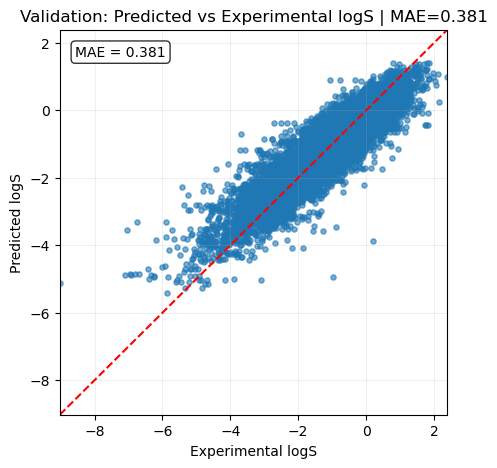

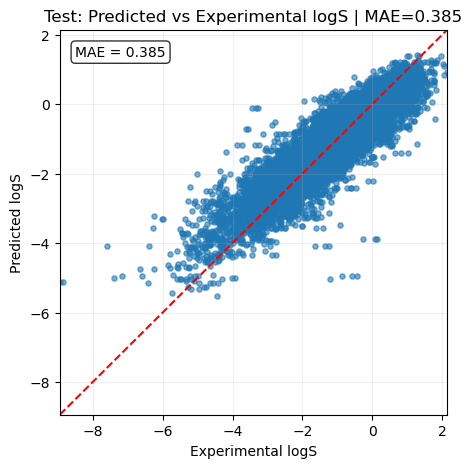

In [10]:
import matplotlib.pyplot as plt

def collect_predictions(loader):
    model.eval()
    y_true_all, y_pred_all = [], []
    with torch.no_grad():
        for batch in loader:
            batch = to_device(batch)
            y = batch['y']
            pred = model(batch)
            y_true_all.append(y.detach().cpu().numpy())
            y_pred_all.append(pred.detach().cpu().numpy())
    return np.concatenate(y_true_all), np.concatenate(y_pred_all)

def plot_parity(y_true, y_pred, title):
    mae = mean_absolute_error(y_true, y_pred)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, s=14, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)
    plt.xlabel('Experimental logS')
    plt.ylabel('Predicted logS')
    plt.title(f"{title} | MAE={mae:.3f}")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.text(0.04, 0.96, f"MAE = {mae:.3f}", transform=plt.gca().transAxes,
             ha='left', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.grid(alpha=0.2)
    plt.show()

val_true, val_pred = collect_predictions(val_loader)
test_true, test_pred = collect_predictions(test_loader)
plot_parity(val_true, val_pred, 'Validation: Predicted vs Experimental logS')
plot_parity(test_true, test_pred, 'Test: Predicted vs Experimental logS')

Text(0, 0.5, 'RMSE')

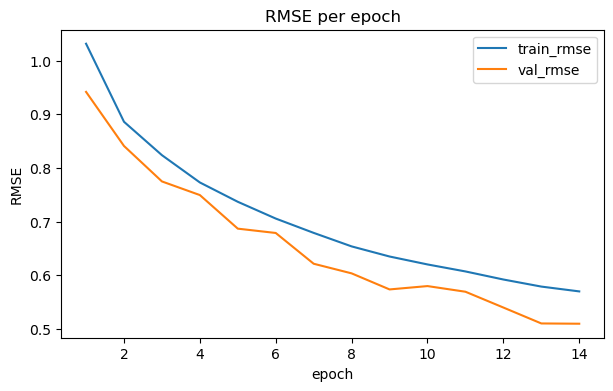

In [11]:
history_df = pd.DataFrame(history)
ax = history_df.plot(x='epoch', y=['train_rmse', 'val_rmse'], figsize=(7,4), title='RMSE per epoch')
ax.set_ylabel('RMSE')

In [12]:
def prepare_single(solute_smiles: str, solvent_smiles: str):
    g_m = mol_to_graph(solute_smiles)
    g_s = mol_to_graph(solvent_smiles)
    if g_m is None:
        raise ValueError(f'Invalid solute SMILES: {solute_smiles}')
    if g_s is None:
        raise ValueError(f'Invalid solvent SMILES: {solvent_smiles}')
    batch = collate_fn([{'mol': g_m, 'sol': g_s, 'y': 0.0}])
    return {k: v.to(DEVICE) for k, v in batch.items()}

def predict_logS(solute_smiles: str, solvent_smiles: str):
    model.eval()
    with torch.no_grad():
        return model(prepare_single(solute_smiles, solvent_smiles)).item()

In [13]:
print('Example logS prediction:', predict_logS('CCO', 'O'))

Example logS prediction: -1.7135449647903442


In [14]:
from pathlib import Path

checkpoint_dir = Path('../checkpoints')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / f'interaction_solubility_gnn_{run_id}.pt'

torch.save({

    'state_dict': model.state_dict(),

    'config': {

        'in_dim': feat_dim,

        'hidden_dim': HIDDEN_DIM,

        'steps': MESSAGE_STEPS,

        'dropout': DROPOUT,

    }

}, checkpoint_path)

print(f'Saved {checkpoint_path}')

if MLFLOW_AVAILABLE:

    mlflow.log_artifact(str(checkpoint_path))

    mlflow.pytorch.log_model(model, artifact_path='model')

    mlflow.end_run()



2026/02/19 14:12:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/19 14:12:31 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Saved ../checkpoints/interaction_solubility_gnn_5cac23884e714e2c8c25a1032c9d5b92.pt


Open MLflow UI (run from `solubility-dual-graph/` directory):

```bash
mlflow ui --backend-store-uri sqlite:///../mlruns/mlflow.db
```
